# Generative Shape Variational Autoencoder (VAE): Interactive Sampling Demo

This notebook trains the sparse voxel shape [variational autoencoder](https://arxiv.org/abs/1312.6114) (VAE) from [`examples/shape_vae.py`](../examples/shape_vae.py) and then explores its latent space interactively:
reconstructing shapes, sampling novel shapes from the prior, and interpolating between shapes.

The model is built from three fvdb pieces:

- **Generative transposed convolutions** — `fvdb.ConvolutionPlan.from_grid_batch_transposed(..., target_grid=None)`
  generates the complete (uncropped) transposed support, so the decoder can *create new voxel coordinates*.
- **`fvdb.nn.Prune`** — trims the generated topology with a per-voxel keep mask predicted by a classifier at
  each level.
- A **ground-truth pyramid** built with `GridBatch.conv_grid(2, 2)` supplies per-level occupancy targets.

Training takes about 1–2 minutes on a GPU.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import torch
import tqdm

# Reuse the data pipeline, model, and losses from examples/shape_vae.py.
repo_root = next(p for p in (pathlib.Path.cwd() / "..", pathlib.Path.cwd()) if (p / "examples" / "shape_vae.py").exists())
sys.path.insert(0, str((repo_root / "examples").resolve()))
import shape_vae as sv

torch.random.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda

## The dataset

The 254-model "Shoe" category of [Scanned Objects by Google Research](https://app.gazebosim.org/GoogleResearch)
(CC-BY 4.0, bundled with fvdb-example-data — see its `ATTRIBUTION.json` for per-model attribution). Each mesh is
voxelized to a sparse grid at resolution 64 inside the unit cube; the whole dataset is one pre-voxelized
`GridBatch`, and the input features are just a constant 1 per voxel — the network learns *topology*, not
appearance. One object category with real intra-class variation (runners, boat shoes, ballet flats, boots)
is exactly what makes latent-space interpolation and sampling interesting.

In [2]:
import json

from fvdb.utils.examples import get_fvdb_example_data_path

gt_grid = sv.prepare_shapes(device)
with open(get_fvdb_example_data_path() / "meshes" / "gso_shoes" / "ATTRIBUTION.json") as fp:
    shape_names = [m["name"] for m in json.load(fp)["models"]]
print(f"{gt_grid.grid_count} shapes, {gt_grid.total_voxels} voxels total")

254 shapes, 1737209 voxels total

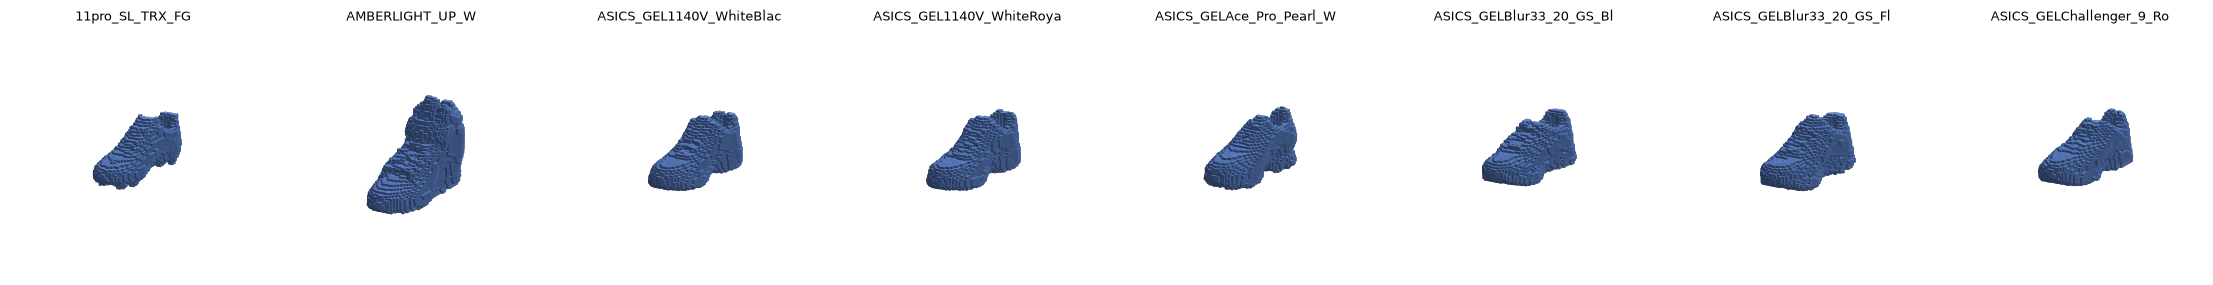

In [3]:
import numpy as np
import point_cloud_utils as pcu
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def voxel_surface(ijk: np.ndarray, voxel_size: float) -> np.ndarray:
    """Triangles of the exposed voxel-cube faces (interior faces between adjacent voxels culled)."""
    v, f = pcu.voxel_grid_geometry(ijk, voxel_size)
    tris = v[f]
    centroids = np.round(tris.mean(axis=1) / (voxel_size * 0.25)).astype(np.int64)
    _, inverse, counts = np.unique(centroids, axis=0, return_inverse=True, return_counts=True)
    return tris[counts[inverse] == 1]


def lambert_colors(tris: np.ndarray, base_rgb=(0.45, 0.62, 0.95), light=(0.4, 0.6, 1.0)) -> np.ndarray:
    normals = np.cross(tris[:, 1] - tris[:, 0], tris[:, 2] - tris[:, 0])
    normals /= np.linalg.norm(normals, axis=1, keepdims=True) + 1e-12
    light_dir = np.asarray(light) / np.linalg.norm(light)
    lambert = 0.35 + 0.65 * np.clip(normals @ light_dir, 0.0, 1.0)
    return np.clip(lambert[:, None] * np.asarray(base_rgb)[None, :], 0.0, 1.0)


def plot_grids(grids_and_titles, panel_size=2.8):
    """Render each (GridBatch, batch_index, title) triple as a lit voxel surface in a row of 3D axes.

    The GSO scans follow the Gazebo z-up convention, so axes are plotted unswapped.
    """
    n = len(grids_and_titles)
    fig = plt.figure(figsize=(panel_size * n, panel_size))
    for i, (grid, b, title) in enumerate(grids_and_titles):
        ax = fig.add_subplot(1, n, i + 1, projection="3d")
        if grid.num_voxels_at(b) > 0:
            ijk = grid.ijk[b].jdata.cpu().numpy()
            tris = voxel_surface(ijk, 1.0 / sv.RESOLUTION)
            ax.add_collection3d(Poly3DCollection(tris, facecolors=lambert_colors(tris), edgecolors="none"))
            lo, hi = tris.reshape(-1, 3).min(axis=0), tris.reshape(-1, 3).max(axis=0)
            center, half = (lo + hi) / 2, (hi - lo).max() / 2 * 1.05
            ax.set_xlim(center[0] - half, center[0] + half)
            ax.set_ylim(center[1] - half, center[1] + half)
            ax.set_zlim(center[2] - half, center[2] + half)
        ax.set_box_aspect((1, 1, 1))
        ax.view_init(elev=18, azim=-60)
        ax.set_title(title, fontsize=9)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()


plot_grids([(gt_grid, b, shape_names[b][:24]) for b in range(8)])

## Training

The encoder strides each shape down four levels and global-average-pools into a 128-dimensional latent
(`mu`, `logvar`). The decoder broadcasts a latent over a dense $4^3$ "neck" grid (plus a learned positional
embedding) and then alternates generative transposed convolution → occupancy classifier → `Prune` for four
levels back to full resolution. While training, the keep mask is teacher-forced with the ground truth
(`keep |= target`). The loss is per-level binary cross-entropy plus a
down-weighted KL term.

Each iteration trains on a random minibatch: the ground-truth `conv_grid(2, 2)` pyramid is built once for
the whole dataset, and a minibatch just sub-indexes every level (`GridBatch` indexing is cheap; per-iteration
CPU work — notably `ConvolutionPlan` construction for the changing generated topologies — is what bounds
throughput here).

In [4]:
model = sv.ShapeVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=sv.LEARNING_RATE)
gt_pyramid = sv.build_gt_pyramid(gt_grid)

model.train()
for iteration in tqdm.trange(sv.NUM_ITERATIONS, desc="training"):
    idx = torch.randperm(gt_grid.grid_count)[: sv.BATCH_SIZE]
    batch_gt = gt_grid[idx]
    batch_pyramid = [level[idx] for level in gt_pyramid]
    batch_features = batch_gt.jagged_like(torch.ones(batch_gt.total_voxels, 1, device=device))

    logits, targets, _, _, mu, logvar = model(batch_features, batch_gt, batch_pyramid)
    loss, bce, kld = sv.vae_loss(logits, targets, mu, logvar)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
print(f"final loss {loss.item():.4f} (bce {bce.item():.4f}, kld {kld.item():.4f})")

training: 100%|██████████| 1000/1000 [01:05<00:00, 15.26it/s]

final loss 0.2713 (bce 0.2668, kld 0.4484)

## Reconstructions

Encode the training shapes and decode from `z = mu` with **no teacher forcing** — the decoder keeps only
the voxels its classifiers predict. We keep the full dataset's latents (`mu`) around for the interpolation
and interactive cells below.

reconstruction IoU on 4 shapes: 0.345

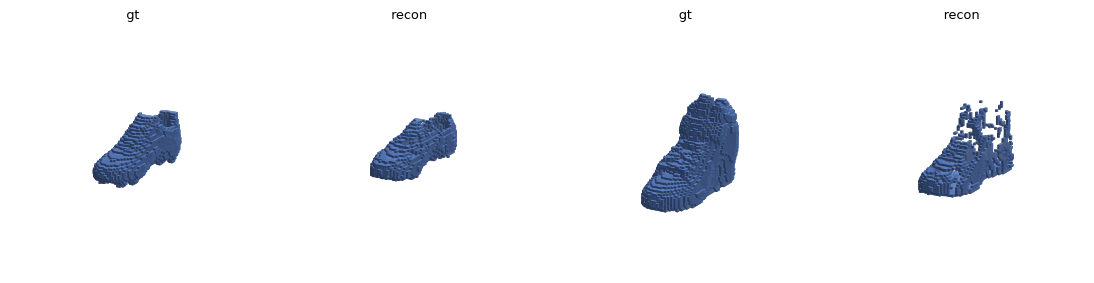

In [5]:
model.eval()
with torch.no_grad():
    all_features = gt_grid.jagged_like(torch.ones(gt_grid.total_voxels, 1, device=device))
    mu, _ = model.encoder(all_features, gt_grid)

    eval_gt = gt_grid[list(range(4))]
    _, _, _, recon_grid = model.decoder(mu[:4], None)
print(f"reconstruction IoU on 4 shapes: {sv.grid_iou(recon_grid, eval_gt):.3f}")

plot_grids(
    [(gt_grid, 0, "gt"), (recon_grid, 0, "recon"), (gt_grid, 1, "gt"), (recon_grid, 1, "recon")]
)

## Sampling novel shapes from the prior

Because the decoder never sees the encoder's topology (no skip connections), we can decode latents drawn
from the prior, $z \sim \mathcal{N}(0, I)$, and get novel shoes that are not in the training set.

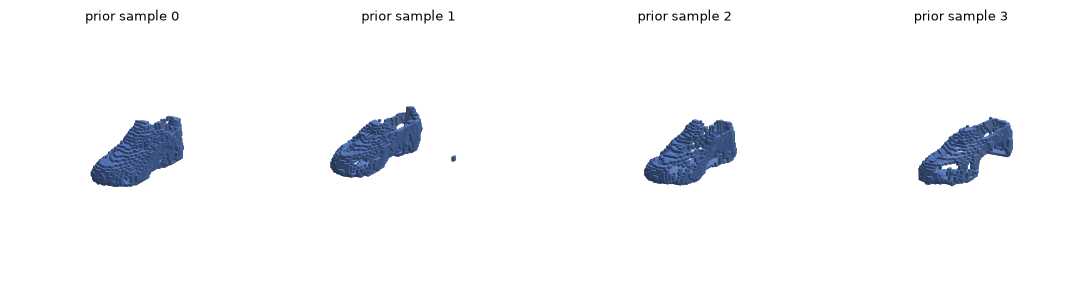

In [6]:
def decode_latents(z: torch.Tensor):
    """Decode a (batch, LATENT_DIM) tensor of latents into a GridBatch of generated topologies."""
    with torch.no_grad():
        _, _, _, grid = model.decoder(z, None)
    return grid


z = torch.randn(4, sv.LATENT_DIM, device=device)
samples = decode_latents(z)
plot_grids([(samples, b, f"prior sample {b}") for b in range(samples.grid_count)])

## Latent interpolation

Walk a straight line between two shapes' latents and decode each step. All the steps are decoded in one
batched call — the generated `GridBatch` simply has one grid per interpolation step.

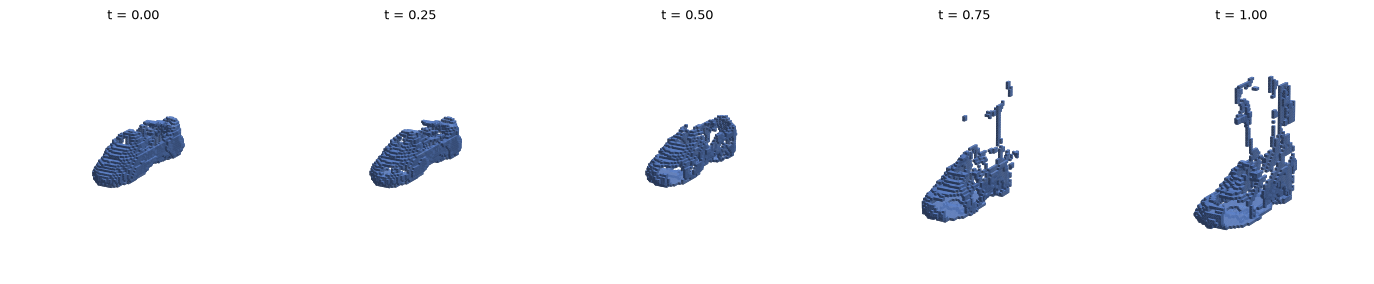

In [7]:
def interpolate(source: int, target: int, num_steps: int = 5):
    t = torch.linspace(0.0, 1.0, num_steps, device=device).unsqueeze(1)
    grids = decode_latents((1.0 - t) * mu[source] + t * mu[target])
    plot_grids([(grids, i, f"t = {t[i].item():.2f}") for i in range(num_steps)])


def find_shape(substring: str) -> int:
    return next(i for i, n in enumerate(shape_names) if substring in n)


flat_idx = find_shape("Tieks")  # a ballet flat
boot_idx = find_shape("UGG_Classic_Tall")  # a tall boot
interpolate(source=flat_idx, target=boot_idx)

## Interactive latent explorer

If `ipywidgets` is installed (it ships with the `fvdb_learn` environment), the cell below gives you live
controls: pick two shapes, blend between them, and add prior noise. Each slider move decodes a fresh
topology through the generative decoder. Without `ipywidgets` (e.g. in CI), a single static frame is shown
instead.

In [8]:
def explore(source: int, target: int, t: float, noise: float):
    z = (1.0 - t) * mu[source] + t * mu[target] + noise * torch.randn(sv.LATENT_DIM, device=device)
    decoded = decode_latents(z.unsqueeze(0))
    plot_grids(
        [
            (gt_grid, source, shape_names[source][:24]),
            (decoded, 0, f"decoded (t={t:.2f}, noise={noise:.1f})"),
            (gt_grid, target, shape_names[target][:24]),
        ]
    )


try:
    import ipywidgets

    n = gt_grid.grid_count
    ipywidgets.interact(
        explore,
        source=ipywidgets.IntSlider(min=0, max=n - 1, value=flat_idx, description="from"),
        target=ipywidgets.IntSlider(min=0, max=n - 1, value=boot_idx, description="to"),
        t=ipywidgets.FloatSlider(min=0.0, max=1.0, step=0.05, value=0.5, description="blend"),
        noise=ipywidgets.FloatSlider(min=0.0, max=2.0, step=0.1, value=0.0, description="noise"),
    )
except ImportError:
    print("ipywidgets is not installed - showing a single static frame instead.")
    print("Install it (`pip install ipywidgets`) and re-run this cell for live sliders.")
    explore(source=flat_idx, target=boot_idx, t=0.5, noise=0.0)

interactive(children=(IntSlider(value=17, description='from', max=253), IntSlider(value=199, description='to',…